# 🎨 DDPM — Generative AI Assignment 4
**NUCES | AI4009 | Spring 2026**

In [1]:
# Install & Imports
!pip install -q scikit-image gradio

import os, math, glob, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T
from torchvision.utils import make_grid
from skimage.metrics import peak_signal_noise_ratio as calc_psnr
from skimage.metrics import structural_similarity as calc_ssim

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [2]:
# Mount Drive & Download Dataset
from google.colab import drive
drive.mount('/content/drive')

os.environ['KAGGLE_USERNAME'] = 'YOUR_USERNAME'   # 👈 fill this
os.environ['KAGGLE_KEY']      = 'YOUR_API_KEY'    # 👈 fill this

!pip install -q kaggle
!kaggle datasets download -d denislukovnikov/celebahq256-images-only -p /content/celeba/
!unzip -q /content/celeba/celebahq256-images-only.zip -d /content/celeba/
print('Dataset ready!')

Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/denislukovnikov/celebahq256-images-only
License(s): unknown
100% 2.81G/2.81G [00:30<00:00, 101MB/s]

Dataset ready!


In [3]:

BATCH      = 16
EPOCHS     = 20
LR         = 2e-4
T_STEPS    = 400       # diffusion timesteps
DIM        = 64        # base channel dim → 64, 128, 256
DATA_PATH  = '/content/celeba/'
OUT_DIR    = '/content/results'
os.makedirs(OUT_DIR, exist_ok=True)
print('Config done')

Config done


In [4]:
# Dataset
class FaceDataset(Dataset):
    def __init__(self, root, size=128, train=True):
        paths = glob.glob(os.path.join(root, '**', '*.jpg'), recursive=True) + \
                glob.glob(os.path.join(root, '**', '*.png'), recursive=True)
        if not paths: raise RuntimeError(f'No images in {root}')
        random.shuffle(paths)
        cut = int(len(paths) * 0.95)
        self.paths = paths[:cut] if train else paths[cut:]
        self.tf = T.Compose([
            T.Resize((size, size)), T.RandomHorizontalFlip(),
            T.ToTensor(), T.Normalize([0.5]*3, [0.5]*3)
        ])
    def __len__(self): return len(self.paths)
    def __getitem__(self, i): return self.tf(Image.open(self.paths[i]).convert('RGB'))

train_ds = FaceDataset(DATA_PATH, IMG_SIZE, train=True)
val_ds   = FaceDataset(DATA_PATH, IMG_SIZE, train=False)
train_dl = DataLoader(train_ds, BATCH, shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
val_dl   = DataLoader(val_ds,   BATCH, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')

Train: 28500 | Val: 1500


In [5]:
# Noise Scheduler (Forward + Reverse)
class Scheduler:
    def __init__(self, T=400):
        self.T    = T
        b         = torch.linspace(1e-4, 0.02, T)          # beta schedule
        a         = 1 - b                                   # alpha
        ab        = torch.cumprod(a, 0)                     # alpha_bar (ᾱ)
        self.b    = b;  self.a = a;  self.ab = ab
        self.ab_p = F.pad(ab[:-1], (1,0), value=1.0)

    def _g(self, v, t, shape):
        return v.to(t.device)[t].reshape(t.shape[0], *([1]*(len(shape)-1)))

    def add_noise(self, x0, t, noise=None):  # forward q(x_t | x_0)
        if noise is None: noise = torch.randn_like(x0)
        s1 = self._g(self.ab.sqrt(),       t, x0.shape)
        s2 = self._g((1-self.ab).sqrt(),   t, x0.shape)
        return s1*x0 + s2*noise, noise

    @torch.no_grad()
    def sample_step(self, model, xt, t_idx):
        t = torch.full((xt.shape[0],), t_idx, device=xt.device, dtype=torch.long)
        eps    = model(xt, t)
        b_t    = self._g(self.b,  t, xt.shape)
        a_t    = self._g(self.a,  t, xt.shape)
        ab_t   = self._g(self.ab, t, xt.shape)
        mean   = (1/a_t.sqrt()) * (xt - b_t/(1-ab_t).sqrt() * eps)
        if t_idx == 0: return mean
        var = b_t * (1 - self._g(self.ab_p, t, xt.shape)) / (1 - ab_t)
        return mean + var.sqrt() * torch.randn_like(xt)

    @torch.no_grad()
    def generate(self, model, n, save_steps=5):
        x = torch.randn(n, 3, IMG_SIZE, IMG_SIZE, device=device)
        steps, gap = [x.cpu()], max(1, self.T // save_steps)
        for i in tqdm(reversed(range(self.T)), desc='Sampling', leave=False, total=self.T):
            x = self.sample_step(model, x, i)
            if i % gap == 0: steps.append(x.cpu())
        return x.cpu(), steps

sched = Scheduler(T_STEPS)
print('Scheduler ready')

Scheduler ready


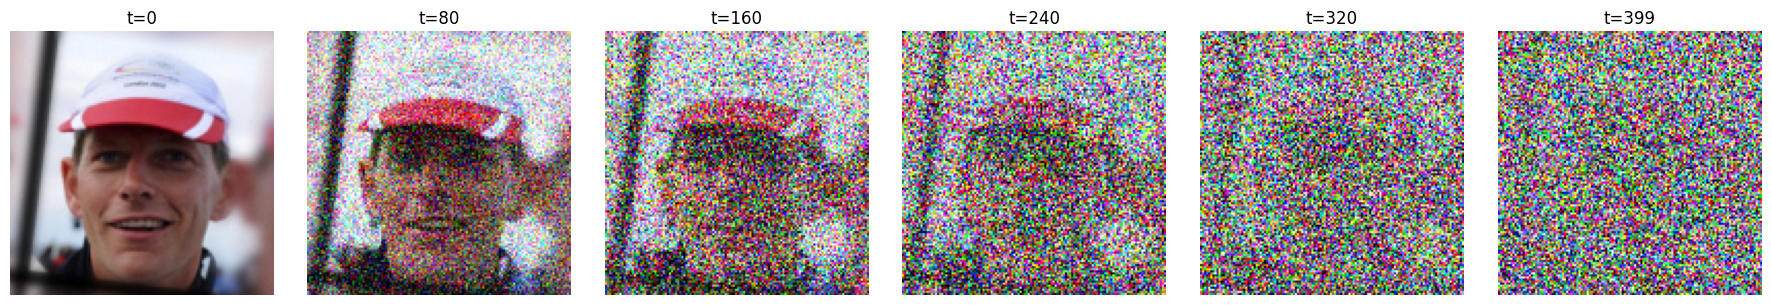

In [6]:
# Visualize Forward Diffusion
def show(imgs, titles, fname):
    fig, ax = plt.subplots(1, len(imgs), figsize=(3*len(imgs), 3))
    for a, img, t in zip(ax, imgs, titles):
        a.imshow((img.permute(1,2,0).numpy()*0.5+0.5).clip(0,1)); a.set_title(t); a.axis('off')
    plt.tight_layout(); plt.savefig(f'{OUT_DIR}/{fname}', dpi=120); plt.show()

x0 = train_ds[0].unsqueeze(0)
steps_viz = [0, 80, 160, 240, 320, 399]
noisy_imgs = [sched.add_noise(x0, torch.tensor([t]))[0].squeeze(0) for t in steps_viz]
show(noisy_imgs, [f't={t}' for t in steps_viz], 'forward_diffusion.png')

In [7]:
# U-Net Architecture
# Time embedding
class TimeEmb(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(d, d*4), nn.GELU(), nn.Linear(d*4, d*4))
        self.d = d
    def forward(self, t):
        h = self.d // 2
        e = math.log(10000) / (h-1)
        e = torch.exp(torch.arange(h, device=t.device) * -e)
        e = t[:,None].float() * e[None,:]
        e = torch.cat([e.sin(), e.cos()], -1)
        return self.mlp(e)

# Residual block with time injection
class ResBlock(nn.Module):
    def __init__(self, ci, co, td):
        super().__init__()
        self.n1  = nn.GroupNorm(8, ci)
        self.c1  = nn.Conv2d(ci, co, 3, padding=1)
        self.n2  = nn.GroupNorm(8, co)
        self.c2  = nn.Conv2d(co, co, 3, padding=1)
        self.te  = nn.Linear(td, co*2)     # scale + shift
        self.sk  = nn.Conv2d(ci, co, 1) if ci != co else nn.Identity()
    def forward(self, x, t):
        h = self.c1(F.silu(self.n1(x)))
        s, b = self.te(t)[:,:,None,None].chunk(2, 1)
        h = self.c2(F.silu(self.n2(h) * (1+s) + b))
        return h + self.sk(x)

# Attention block
class Attn(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.n = nn.GroupNorm(8, c)
        self.q = nn.Conv2d(c, c, 1); self.k = nn.Conv2d(c, c, 1); self.v = nn.Conv2d(c, c, 1)
        self.o = nn.Conv2d(c, c, 1)
    def forward(self, x):
        B,C,H,W = x.shape; h = self.n(x)
        q,k,v = self.q(h).flatten(2), self.k(h).flatten(2), self.v(h).flatten(2)
        w = torch.softmax(torch.bmm(q.permute(0,2,1), k) / C**0.5, -1)
        return x + self.o(torch.bmm(v, w.permute(0,2,1)).view(B,C,H,W))

# Full U-Net: 64 → 128 → 256 → 128 → 64
class UNet(nn.Module):
    def __init__(self, d=64):
        super().__init__()
        td = d*4
        self.te   = TimeEmb(d)
        self.cin  = nn.Conv2d(3, d, 3, padding=1)

        # Encoder
        self.d1   = ResBlock(d,   d,   td);  self.down1 = nn.Conv2d(d,   d,   4,2,1)
        self.d2   = ResBlock(d,   d*2, td);  self.down2 = nn.Conv2d(d*2, d*2, 4,2,1)
        self.d3   = ResBlock(d*2, d*4, td);  self.down3 = nn.Conv2d(d*4, d*4, 4,2,1)

        # Bottleneck
        self.mid1 = ResBlock(d*4, d*4, td)
        self.attn = Attn(d*4)
        self.mid2 = ResBlock(d*4, d*4, td)

        # Decoder
        self.up3  = nn.ConvTranspose2d(d*4, d*4, 4,2,1); self.u3 = ResBlock(d*8, d*2, td)
        self.up2  = nn.ConvTranspose2d(d*2, d*2, 4,2,1); self.u2 = ResBlock(d*4, d,   td)
        self.up1  = nn.ConvTranspose2d(d,   d,   4,2,1); self.u1 = ResBlock(d*2, d,   td)
        self.cout = nn.Conv2d(d, 3, 1)

    def forward(self, x, t):
        t = self.te(t)
        x = self.cin(x)
        h1 = self.d1(x,  t);  x = self.down1(h1)
        h2 = self.d2(x,  t);  x = self.down2(h2)
        h3 = self.d3(x,  t);  x = self.down3(h3)
        x  = self.mid2(self.attn(self.mid1(x, t)), t)
        x  = self.u3(torch.cat([self.up3(x), h3], 1), t)
        x  = self.u2(torch.cat([self.up2(x), h2], 1), t)
        x  = self.u1(torch.cat([self.up1(x), h1], 1), t)
        return self.cout(x)

model = UNet(DIM).to(device)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
print(f'Params: {sum(p.numel() for p in model.parameters()):,}')

# Sanity check
with torch.no_grad():
    out = model(torch.randn(2,3,IMG_SIZE,IMG_SIZE).to(device), torch.tensor([1,2]).to(device))
print('Output shape:', out.shape, '✅')

Params: 8,437,571
Output shape: torch.Size([2, 3, 128, 128]) ✅


In [8]:
# Training
opt    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched_lr = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EPOCHS)
scaler = GradScaler()
train_losses, val_losses = [], []
best_loss = float('inf')

for epoch in range(1, EPOCHS+1):
    # Train
    model.train(); tloss = 0
    for x in tqdm(train_dl, desc=f'Ep {epoch}/{EPOCHS}', leave=False):
        x = x.to(device)
        t = torch.randint(0, T_STEPS, (x.shape[0],), device=device)
        opt.zero_grad()
        with autocast():
            xt, noise = sched.add_noise(x, t)
            loss = F.mse_loss(model(xt, t), noise)   # MSE: predicted vs actual noise
        scaler.scale(loss).backward()
        scaler.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update()
        tloss += loss.item()

    # Validate
    model.eval(); vloss = 0
    with torch.no_grad():
        for x in val_dl:
            x = x.to(device)
            t = torch.randint(0, T_STEPS, (x.shape[0],), device=device)
            xt, noise = sched.add_noise(x, t)
            vloss += F.mse_loss(model(xt, t), noise).item()

    tl = tloss/len(train_dl); vl = vloss/len(val_dl)
    train_losses.append(tl); val_losses.append(vl)
    sched_lr.step()
    print(f'Ep {epoch:2d} | Train: {tl:.4f} | Val: {vl:.4f}')

    if vl < best_loss:
        best_loss = vl
        torch.save(model.state_dict(), f'{OUT_DIR}/best_model.pth')

print('Training done! Best val loss:', round(best_loss, 4))

/tmp/ipykernel_1811/1488196115.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Ep 1/20:   0%|          | 0/1781 [00:00<?, ?it/s]

/tmp/ipykernel_1811/1488196115.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Ep  1 | Train: 0.0429 | Val: 0.0240


Ep 2/20:   0%|          | 0/1781 [00:00<?, ?it/s]

...

Ep 18 | Train: 0.0192 | Val: 0.0171


Ep 19/20:   0%|          | 0/1781 [00:00<?, ?it/s]

Ep 19 | Train: 0.0194 | Val: 0.0193


Ep 20/20:   0%|          | 0/1781 [00:00<?, ?it/s]

Ep 20 | Train: 0.0189 | Val: 0.0205
Training done! Best val loss: 0.0171


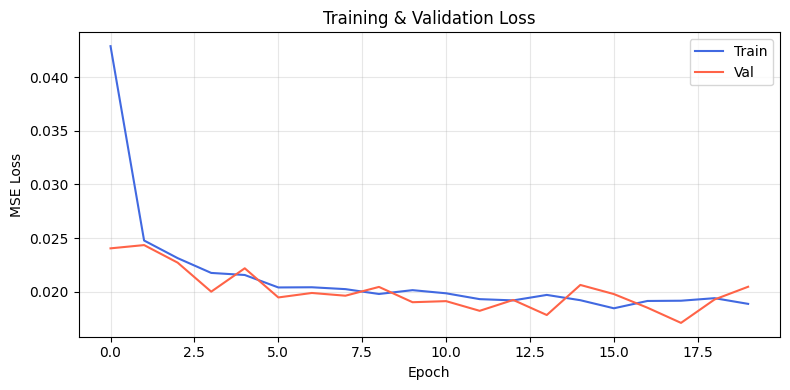

In [9]:
# ── Cell 9: Loss Plot ──────────────────────────────────────────────────────
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train', color='royalblue')
plt.plot(val_losses,   label='Val',   color='tomato')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/loss_curve.png', dpi=120); plt.show()

Sampling:   0%|          | 0/400 [00:00<?, ?it/s]

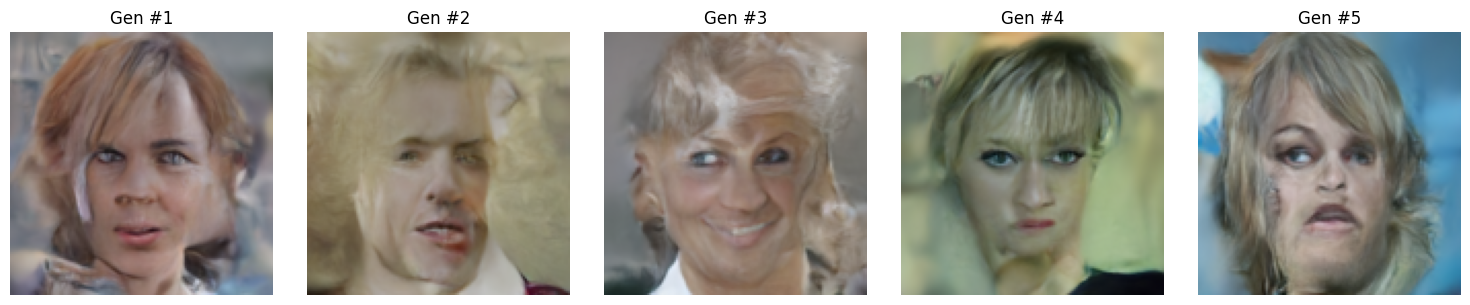

5 images generated ✅


In [10]:
# Generates 5 Images from Pure Noise
model.load_state_dict(torch.load(f'{OUT_DIR}/best_model.pth', map_location=device))
model.eval()

gen_imgs, rev_steps = sched.generate(model, n=5, save_steps=5)

show(
    [gen_imgs[i] for i in range(5)],
    [f'Gen #{i+1}' for i in range(5)],
    'generated_images.png'
)
print('5 images generated ✅')

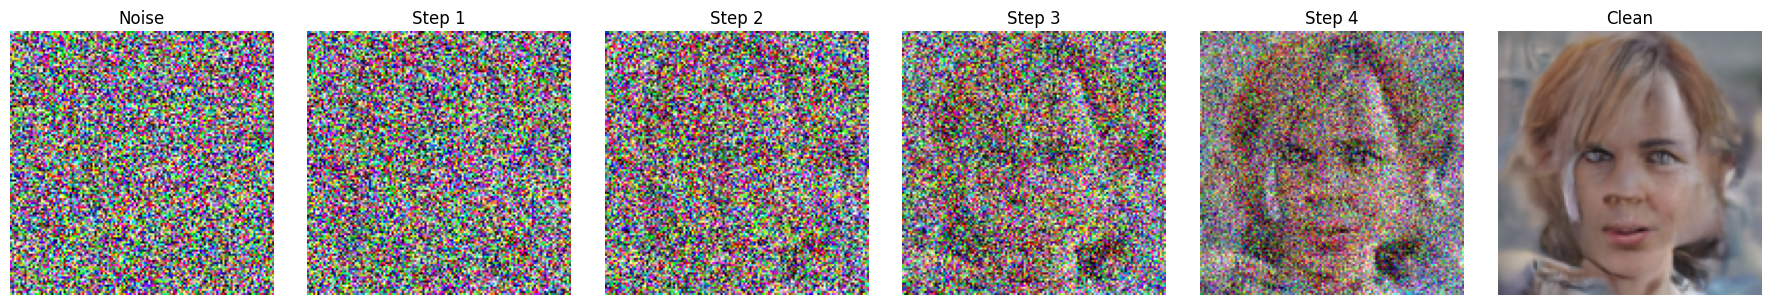

In [11]:
#Visualize Reverse Diffusion ( denoising steps)
show(
    [s[0] for s in rev_steps[:6]],
    ['Noise'] + [f'Step {i+1}' for i in range(4)] + ['Clean'],
    'reverse_diffusion.png'
)

Reconstructing: 0it [00:00, ?it/s]

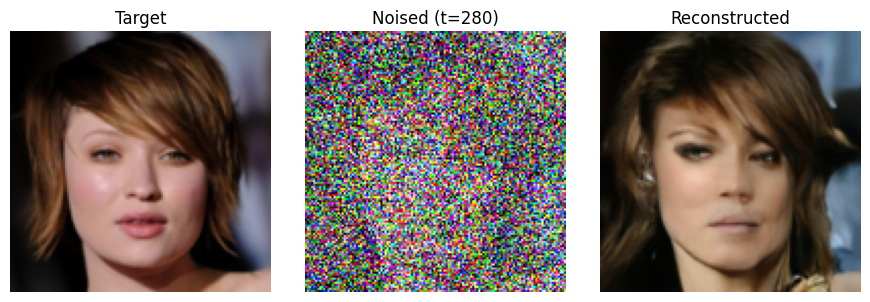

Reconstruction done ✅


In [12]:
#  Image Reconstruction
def reconstruct(target_tensor, noise_ratio=0.7):
    t_start = int(T_STEPS * noise_ratio)
    x0 = target_tensor.unsqueeze(0).to(device)
    t  = torch.tensor([t_start], device=device)
    xt, _ = sched.add_noise(x0, t)         # noise the target

    x = xt.clone()
    for i in tqdm(reversed(range(t_start)), desc='Reconstructing', leave=False):
        x = sched.sample_step(model, x, i)  # reverse from t_start → 0

    show(
        [target_tensor, xt.squeeze(0).cpu(), x.squeeze(0).cpu()],
        ['Target', f'Noised (t={t_start})', 'Reconstructed'],
        'reconstruction.png'
    )
    return x.squeeze(0).cpu()

target = val_ds[0]
recon  = reconstruct(target)
print('Reconstruction done ✅')

In [13]:
#  PSNR & SSIM
def to_np(t): return (t.permute(1,2,0).numpy()*0.5+0.5).clip(0,1)

orig_np  = to_np(target)
recon_np = to_np(recon)

psnr = calc_psnr(orig_np, recon_np, data_range=1.0)
ssim = calc_ssim(orig_np, recon_np, data_range=1.0, channel_axis=-1)

print(f'PSNR : {psnr:.2f} dB')
print(f'SSIM : {ssim:.4f}  (max = 1.0)')

PSNR : 19.77 dB
SSIM : 0.4871  (max = 1.0)


In [14]:
# Gradio App
import gradio as gr

def generate_app(seed=42):
    torch.manual_seed(int(seed)); model.eval()
    imgs, steps = sched.generate(model, n=1, save_steps=5)

    # Final image
    final = Image.fromarray((to_np(imgs[0])*255).astype(np.uint8))

    # Denoising steps grid
    step_pils = [Image.fromarray((to_np(s[0])*255).astype(np.uint8)) for s in steps]
    W, H = step_pils[0].size
    grid = Image.new('RGB', (W*len(step_pils), H))
    for i,p in enumerate(step_pils): grid.paste(p, (i*W, 0))
    return final, grid

with gr.Blocks(title='DDPM Generator') as app:
    gr.Markdown('## 🎨 DDPM Face Generator | AI4009 Assignment 4')
    seed = gr.Slider(0, 9999, value=42, label='Seed')
    btn  = gr.Button('Generate', variant='primary')
    with gr.Row():
        out1 = gr.Image(label='Generated Image')
        out2 = gr.Image(label='Denoising Steps')
    btn.click(generate_app, inputs=seed, outputs=[out1, out2])

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6adf205688b3655e0f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ── Cell 15: Final Checklist ───────────────────────────────────────────────
checks = [
    'Dataset loaded & preprocessed (128x128, normalized)',
    'Forward diffusion visualized (5 steps)',
    'U-Net: 64 → 128 → 256 with residual + time embedding',
    'Downsample & Upsample layers',
    'Skip connections in decoder',
    'MSE Loss (predicted noise vs actual noise)',
    'AdamW + Cosine LR scheduler',
    'Mixed precision (GradScaler)',
    'Gradient clipping',
    'Loss curve plotted',
    '5 images generated from pure noise',
    'Reverse diffusion steps visualized',
    'Image reconstruction (target → noisy → clean)',
    f'PSNR: {psnr:.2f} dB | SSIM: {ssim:.4f}',
    'Gradio app deployed',
]
for c in checks: print(f'  ✅ {c}')